In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [2]:
# 1. Load dataset
titanic_data = pd.read_csv("Titanic-Dataset.csv")

In [3]:
# 2. Basic information
print("Dataset Shape:")
print(titanic_data.shape)

print("\nDataset Information:")
titanic_data.info()

print("\nBasic Statistics:")
print(titanic_data.describe())

Dataset Shape:
(891, 12)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Basic Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.30

In [4]:
# 3. Check missing values
print("\nMissing Values:")
print(titanic_data.isnull().sum())


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# 4. Handle missing Age using median
titanic_data["Age"] = titanic_data["Age"].fillna(
    titanic_data["Age"].median()
)

In [6]:
# 5. Handle missing Embarked using mode
titanic_data["Embarked"] = titanic_data["Embarked"].fillna(
    titanic_data["Embarked"].mode()[0]
)

In [7]:
# 6. Remove Cabin because it has many missing values
titanic_data = titanic_data.drop("Cabin", axis=1)

In [8]:
# 7. Encode Sex using LabelEncoder
label_encoder = LabelEncoder()

titanic_data["Sex"] = label_encoder.fit_transform(
    titanic_data["Sex"]
)

In [9]:
# 8. Encode Embarked using OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(
    titanic_data[["Embarked"]]
)

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["Embarked"])
)

In [10]:
# 9. Add encoded columns
titanic_data = pd.concat(
    [titanic_data, encoded_df],
    axis=1
)

In [11]:
# 10. Remove original Embarked column
titanic_data = titanic_data.drop("Embarked", axis=1)

In [12]:
# 11. Check cleaned dataset
print("\nCleaned Dataset:")
print(titanic_data.head())

print("\nMissing Values After Cleaning:")
print(titanic_data.isnull().sum())

print("\nFinal Shape:")
print(titanic_data.shape)


Cleaned Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare  Embarked_C  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500         0.0         0.0         1.0  
1          PC 17599  71.2833         1.0         0.0         0.0  
2  STON/O2. 3101282   7.9250         0.0         0.0         1.0  
3         

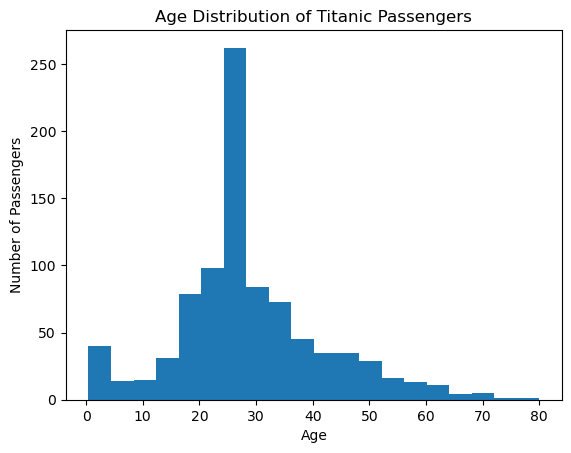

In [13]:
# 12. Visualize Age Distribution
plt.hist(titanic_data["Age"], bins=20)

plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Age Distribution of Titanic Passengers")

plt.show()

In [14]:
# 13. Save cleaned dataset
titanic_data.to_csv(
    "titanic_cleaned.csv",
    index=False
)

print("\nCleaned dataset saved successfully!")


Cleaned dataset saved successfully!
